# Trabalho Prático 1: Encontrando Exoplanetas com Machine Learning

#### Aluno: *Pedro Dias Soares*

## Tópicos
### 1. Introdução e Entendimento do Problema
Nesta seção, contextualizaremos o uso do telescópio espacial Kepler e o desafio astrofísico de diferenciar a assinatura luminosa de um exoplaneta genuíno das anomalias instrumentais conhecidas como falsos positivos.

#### 1.1 Dicionário de Dados
Aqui detalharemos o significado das principais variáveis observadas (como profundidade do trânsito, temperatura da estrela, etc.), com destaque para a nossa variável alvo categórica: `koi_disposition`.

---

### 2. Importação dos Dados
Carga do arquivo `koi_data.csv` para o ambiente de desenvolvimento e visualização inicial das primeiras linhas para checagem de integridade.

---

### 3. Prevenção de Data Leakage e Separação de Dados
O conjunto de dados será dividido antes de qualquer transformação: 70% para a base de treinamento e 30% separados (hold-out) para o teste final.

---

### 4. Limpeza e Tratamento de Dados Ausentes
Tratamento de valores nulos e inconsistências sintáticas/semânticas. Cálculos de preenchimento utilizarão estatísticas do conjunto de treinamento.

---

### 5. Seleção de Atributos
Análise exploratória para remover colunas irrelevantes ou que causem a maldição da dimensionalidade. As escolhas de exclusão serão justificadas com base no domínio do problema.

---

### 6. Transformação de Dados
Aplicação de técnicas de normalização.

---

### 7. Balanceamento de Classes
Estratégias para lidar com a diferença de volume entre as classes de exoplanetas confirmados e falsos positivos, aplicadas de forma isolada no conjunto de treino.

---

### 8. Treinamento, Validação Cruzada e Ajuste de Hiperparâmetros
Implementação do dicionário de modelos contendo os seis algoritmos requisitados: 
1. Naive Bayes;
2. Decision Tree;
3. k-Nearest Neighbors (k-NN);
4. Support Vector Machines (SVM);
5. Random Forest;
6. Gradient Tree Boosting;

Os ajustes serão validados via Cross-Validation usando apenas os 70% de treino.

---

### 9. Avaliação no Conjunto de Teste
Aplicação dos modelos otimizados sobre os 30% de dados intocados para simular o comportamento algorítmico no mundo real.

---

### 10. Resultados e Análise Crítica
#### 10.1 Métricas e Matrizes de Confusão
Extração das métricas vitais para o domínio astrofísico, com foco na Sensibilidade (Recall) e na convergência da Equação harmônica do F1-Score através das Matrizes de Confusão.

#### 10.2 Conclusão
Comparativo de desempenho entre as arquiteturas, interpretando o real impacto das decisões de pré-processamento nos resultados e atestando a corretude conceitual do experimento.

---

### 11. Referencial Teórico

## 1. Introdução e Entendimento do Problema

A base de dados empírica utilizada (`koi_data.csv`) provém do telescópio espacial Kepler, uma missão da NASA desenhada para explorar a estrutura e a diversidade de sistemas planetários. O Kepler revolucionou a astronomia ao identificar candidatos a planetas através do **Método de Trânsito** (Borucki et al., 2010). Este método consiste em monitorar continuamente a curva de luz de milhares de estrelas; quando um planeta orbita e cruza a linha de visão do telescópio, ocorre uma micro-queda periódica e detectável no brilho estelar.

### O Desafio dos Falsos Positivos na Astrofísica

Apesar da precisão do método de trânsito, a simples detecção de uma queda de luminosidade não confirma a existência de um exoplaneta. Inúmeros fenômenos astrofísicos e instrumentais mimetizam perfeitamente a assinatura fotométrica de um trânsito real, gerando o que a literatura chama de **Falsos Positivos**. Segundo Morton et al. (2016), as principais fontes de confusão incluem:
* **Sistemas Binários Eclipsantes:** Estrelas companheiras que bloqueiam a luz mutuamente.
* **Manchas Estelares e Variabilidade:** Alterações na própria superfície da estrela hospedeira.
* **Ruído Instrumental:** Anomalias térmicas ou de sensores no próprio telescópio.

### A Abordagem de Aprendizado de Máquina

Historicamente, a triagem (vetting) desses sinais exigia análise humana exaustiva. Com o aumento exponencial do volume de dados, a adoção de técnicas de inteligência artificial tornou-se o padrão-ouro na astronomia moderna (Shallue & Vanderburg, 2018). 

Neste cenário, modelamos o problema como uma tarefa de **Aprendizado de Máquina Supervisionado**. O objetivo deste trabalho é aplicar algoritmos de classificação multicritério sobre atributos físicos e geométricos do trânsito como profundidade da curva, período orbital e temperatura estelar para distinguir automaticamente os exoplanetas da classe `CONFIRMED` das anomalias da classe `FALSE POSITIVE`. O modelo que melhor generalizar esses padrões matemáticos servirá como um filtro autônomo e confiável para futuras missões espaciais.

O objetivo é treinar e comparar múltiplos algoritmos de classificação contendo os seis algoritmos requisitados: 

1. Naive Bayes;
2. Decision Tree;
3. k-Nearest Neighbors (k-NN);
4. Support Vector Machines (SVM);
5. Random Forest;
6. Gradient Tree Boosting; 

---



### 1.1 Dicionário de Dados e Seleção Preliminar

Para que os algoritmos de aprendizado de máquina consigam discernir padrões astrofísicos reais de anomalias, é essencial compreender o significado físico das features coletadas pelo telescópio. O conjunto `koi_data.csv` é extraído do catálogo Kepler Objects of Interest (KOI). De acordo com o Dicionário de Dados Oficial do NASA Exoplanet Archive (2021), as variáveis mais relevantes para a modelagem dividem-se nas seguintes categorias:

#### Variável Alvo
* **`koi_disposition`**: O status de classificação oficial do objeto de interesse. No nosso escopo de classificação binária, esta coluna contém os valores `CONFIRMED` (Exoplaneta confirmado por outras metodologias e publicações) ou `FALSE POSITIVE` (Alarme falso causado por binárias eclipsantes, ruído instrumental, etc.).

#### Características do Trânsito
Estas variáveis descrevem o evento físico da queda de luz captada pelo telescópio.
* **`koi_period`**: O período orbital do candidato, ou seja, o tempo em dias que o objeto leva para completar uma volta ao redor de sua estrela.
* **`koi_duration`**: A duração total do trânsito em horas. Representa o tempo exato em que a luz da estrela ficou bloqueada.
* **`koi_depth`**: A profundidade do trânsito medida em partes por milhão. É a métrica crucial da curva de luz, indicando a fração exata de luminosidade bloqueada pelo objeto.
* **`koi_prad`**: O raio estimado do corpo planetário (em raios terrestres), calculado com base na profundidade do trânsito e no tamanho da estrela.

#### Características da Estrela Hospedeira
O ambiente estelar interfere diretamente na probabilidade de habitabilidade e na validação do planeta.
* **`koi_steff`**: A temperatura efetiva da estrela hospedeira (em Kelvin). Estrelas muito quentes ou muito frias geram curvas de luz com assinaturas de ruído diferentes.
* **`koi_srad`**: O raio fotossférico da estrela (em raios solares). Um trânsito de mesma profundidade em uma estrela gigante implica um objeto muito maior do que em uma estrela anã.
* **`koi_smass`**: A massa da estrela (em massas solares). Fundamental para calcular a força gravitacional e a mecânica orbital do sistema.

## 2. Importação dos Dados

In [1]:
# Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score

In [2]:
caminho_arquivo = '/kaggle/input/datasets/pedrodiassoares/koi-data/koi_data.csv'

df = pd.read_csv(caminho_arquivo)

# Visualização inicial para confirmar a carga e verificar os tipos das colunas
display(df.head())
print("\n--- Informações do Dataset ---")
df.info()

,kepoi_name,koi_disposition,koi_period,koi_impact,koi_duration,koi_depth,koi_ror,koi_srho,koi_prad,koi_sma,...,koi_fwm_srao,koi_fwm_sdeco,koi_fwm_prao,koi_fwm_pdeco,koi_dicco_mra,koi_dicco_mdec,koi_dicco_msky,koi_dikco_mra,koi_dikco_mdec,koi_dikco_msky
0,K00752.01,CONFIRMED,9.48804,0.146,2.95750,615.8,0.02234,3.20796,2.26,0.0853,...,0.430,0.940,-0.00020,-0.00055,-0.010,0.200,0.200,0.080,0.310,0.320
1,K00752.02,CONFIRMED,54.41838,0.586,4.50700,874.8,0.02795,3.02368,2.83,0.2734,...,-0.630,1.230,0.00066,-0.00105,0.390,0.000,0.390,0.490,0.120,0.500
2,K00754.01,FALSE POSITIVE,1.73695,1.276,2.40641,8079.2,0.38739,0.22080,33.46,0.0267,...,-0.111,0.002,0.00302,-0.00142,-0.249,0.147,0.289,-0.257,0.099,0.276
3,K00755.01,CONFIRMED,2.52559,0.701,1.65450,603.3,0.02406,1.98635,2.75,0.0374,...,-0.010,0.230,0.00008,-0.00007,0.030,-0.090,0.100,0.070,0.020,0.070
4,K00114.01,FALSE POSITIVE,7.36179,1.169,5.02200,233.7,0.18339,0.00485,39.21,0.0820,...,-13.450,24.090,0.00303,-0.00555,-4.506,7.710,8.930,-4.537,7.713,8.948



--- Informações do Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5202 entries, 0 to 5201
Data columns (total 43 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   kepoi_name        5202 non-null   object 
 1   koi_disposition   5202 non-null   object 
 2   koi_period        5202 non-null   float64
 3   koi_impact        5202 non-null   float64
 4   koi_duration      5202 non-null   float64
 5   koi_depth         5202 non-null   float64
 6   koi_ror           5202 non-null   float64
 7   koi_srho          5202 non-null   float64
 8   koi_prad          5202 non-null   float64
 9   koi_sma           5202 non-null   float64
 10  koi_incl          5202 non-null   float64
 11  koi_teq           5202 non-null   float64
 12  koi_insol         5202 non-null   float64
 13  koi_dor           5202 non-null   float64
 14  koi_max_sngle_ev  5202 non-null   float64
 15  koi_max_mult_ev   5202 non-null   float64
 16  koi_model_

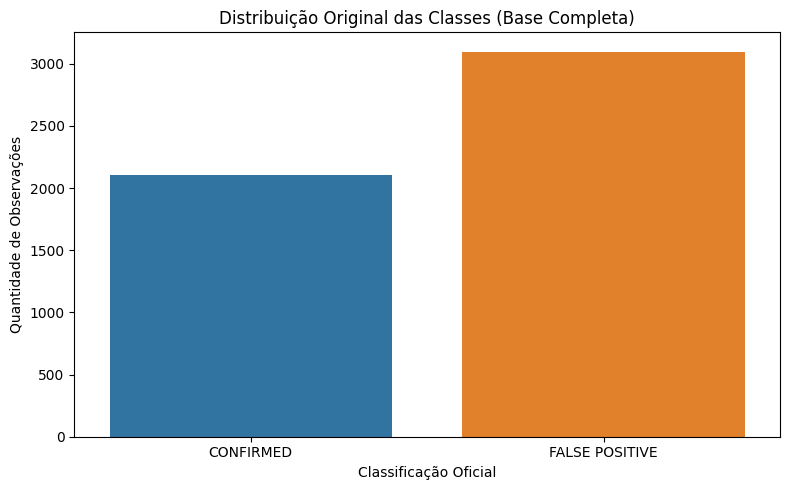

In [3]:
plt.figure(figsize=(8, 5))

# Correção: Adicionado hue='koi_disposition' e legend=False para evitar o erro do Seaborn
sns.countplot(data=df, x='koi_disposition', hue='koi_disposition', palette=['#1f77b4', '#ff7f0e'], legend=False)

plt.title('Distribuição Original das Classes (Base Completa)')
plt.xlabel('Classificação Oficial')
plt.ylabel('Quantidade de Observações')

plt.tight_layout()
plt.show()

**Desbalanceamento Evidente:**
A distribuição inicial comprova que o telescópio Kepler capta significativamente mais anomalias e ruídos do que planetas reais. Há uma predominância clara da classe `FALSE POSITIVE` sobre a `CONFIRMED`. Esta assimetria justifica tecnicamente a aplicação da técnica SMOTE (Tópico 7), garantindo que o modelo não crie um viés de predição para a classe majoritária.

## 3. Prevenção de Data Leakage e Separação de Dados

In [4]:
# Separando a variável alvo (y) das variáveis preditoras (X)
X = df.drop(columns=['koi_disposition'])
y = df['koi_disposition']

# Divisão de 70% para treino e 30% para teste em hold-out
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.30, 
    random_state=42, 
    stratify=y
)

print("\n--- Resultado da Separação ---")
print(f"Tamanho do conjunto de Treino: {X_train.shape[0]} amostras (70%)")
print(f"Tamanho do conjunto de Teste (Intocado): {X_test.shape[0]} amostras (30%)")


--- Resultado da Separação ---
Tamanho do conjunto de Treino: 3641 amostras (70%)
Tamanho do conjunto de Teste (Intocado): 1561 amostras (30%)


## 4. Limpeza e Tratamento de Dados Ausentes

A etapa de limpeza de dados é fundamental para garantir a integridade do modelo.

Como observado na etapa de importação (`df.info()`), o nosso conjunto de dados não possui valores nulos explícitos (NaN). Sendo assim, o problema dispensa a aplicação de métodos de imputação. 

Abaixo, realizamos a validação programática final para atestar que as bases de treino e teste estão 100% preenchidas e verificamos a ausência de registros duplicados, garantindo a representatividade e a diversidade da amostra.

In [5]:
# 1. Verificação de Dados Ausentes (Null/NaN)
null_train = X_train.isnull().sum().sum()
null_test = X_test.isnull().sum().sum()

print("--- Verificação de Dados Ausentes ---")
print(f"Valores nulos no conjunto de Treino (X_train): {null_train}")
print(f"Valores nulos no conjunto de Teste (X_test): {null_test}")

# 2. Verificação de Linhas Duplicadas no Treino
duplicadas_treino = X_train.duplicated().sum()
print(f"\n--- Verificação de Registros Duplicados ---")
print(f"Linhas duplicadas no conjunto de Treino: {duplicadas_treino}")



--- Verificação de Dados Ausentes ---
Valores nulos no conjunto de Treino (X_train): 0
Valores nulos no conjunto de Teste (X_test): 0

--- Verificação de Registros Duplicados ---
Linhas duplicadas no conjunto de Treino: 0


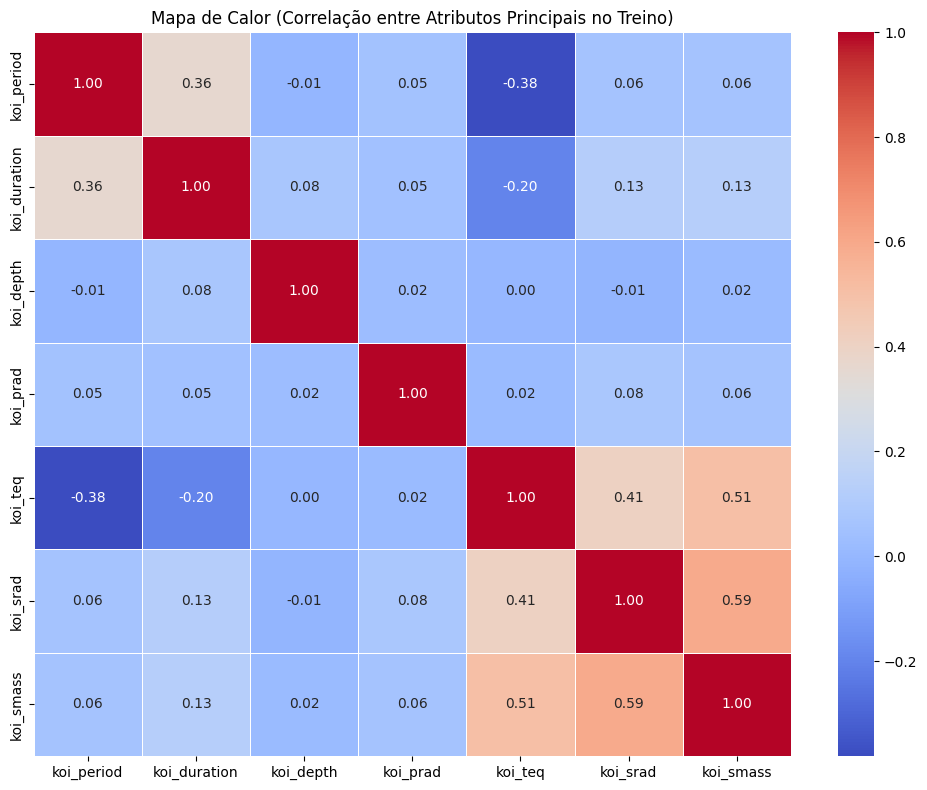

In [6]:
# Selecionamos apenas algumas colunas físicas principais para o gráfico não ficar gigante e ilegível
colunas_principais = ['koi_period', 'koi_duration', 'koi_depth', 'koi_prad', 'koi_teq', 'koi_srad', 'koi_smass']

# Calcula a correlação matemática de Pearson (de -1 a 1) apenas nos dados de treino
matriz_corr = X_train[colunas_principais].corr()

# Configura o tamanho e plota o mapa de calor
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Mapa de Calor (Correlação entre Atributos Principais no Treino)')
plt.tight_layout()
plt.show()

**Independência das Variáveis:**
A matriz de correlação demonstra que, em sua maioria, os atributos físicos do trânsito (como profundidade, período e duração) possuem baixa correlação linear entre si. Isso é um excelente indicativo, pois significa que cada variável traz uma informação única para o algoritmo, reduzindo a redundância.

## 5. Seleção de Atributos e Transformação Categórica

A seleção de atributos visa remover dados que não acrescentam valor físico ou preditivo ao modelo, evitando a introdução de ruído. Neste caso, a variável `kepoi_name` atua apenas como um identificador alfanumérico do catálogo do telescópio Kepler, por isso que será descartada.

Tambem, a variável alvo (`koi_disposition`) encontra-se no formato categórico de texto (`CONFIRMED` e `FALSE POSITIVE`). Como os algoritmos de aprendizagem de máquina requerem matrizes numéricas, é obrigatório aplicar uma técnica de codificação Label Encoding. 

Para respeitar a prevenção de *data leakage*, o codificador será ajustado (`fit`) exclusivamente no conjunto de treino e, posteriormente, aplicado (`transform`) tanto ao treino como ao teste.

In [7]:
# 1. Remoção do Atributo Identificador em ambos os conjuntos
X_train = X_train.drop(columns=['kepoi_name'])
X_test = X_test.drop(columns=['kepoi_name'])

# 2. Transformação Categórica (Label Encoding) da Variável Alvo
le = LabelEncoder()

# O 'fit_transform' é aplicado APENAS no treino para aprender o mapeamento
y_train = le.fit_transform(y_train)

# O 'transform' é aplicado no teste usando o mapeamento aprendido no treino
y_test = le.transform(y_test)

print("--- Resumo após Seleção e Encoding ---")
print(f"Número de atributos preditivos restantes: {X_train.shape[1]}")
print(f"Mapeamento efetuado pelo Encoder: {le.classes_} -> [0, 1]")

--- Resumo após Seleção e Encoding ---
Número de atributos preditivos restantes: 41
Mapeamento efetuado pelo Encoder: ['CONFIRMED' 'FALSE POSITIVE'] -> [0, 1]


## 6. Transformação de Dados

Como os  atributos possuem escalas físicas muito diferentes (por exemplo, a profundidade do trânsito pode estar na casa dos milhares, enquanto a massa da estrela é um valor decimal pequeno), variáveis com maior magnitude podem dominar a função de distância e enviesar o modelo.

Para resolver este problema, aplicaremos a técnica de padronização, que transforma os dados de forma a garantirem uma distribuição com média zero e desvio padrão igual a um. 

Em prevenção de *data leakage*, o padronizador matemático calculará as métricas base (média e desvio padrão) **exclusivamente no conjunto de treino**. De seguida, essa mesma escala será aplicada à transformação do conjunto de teste.

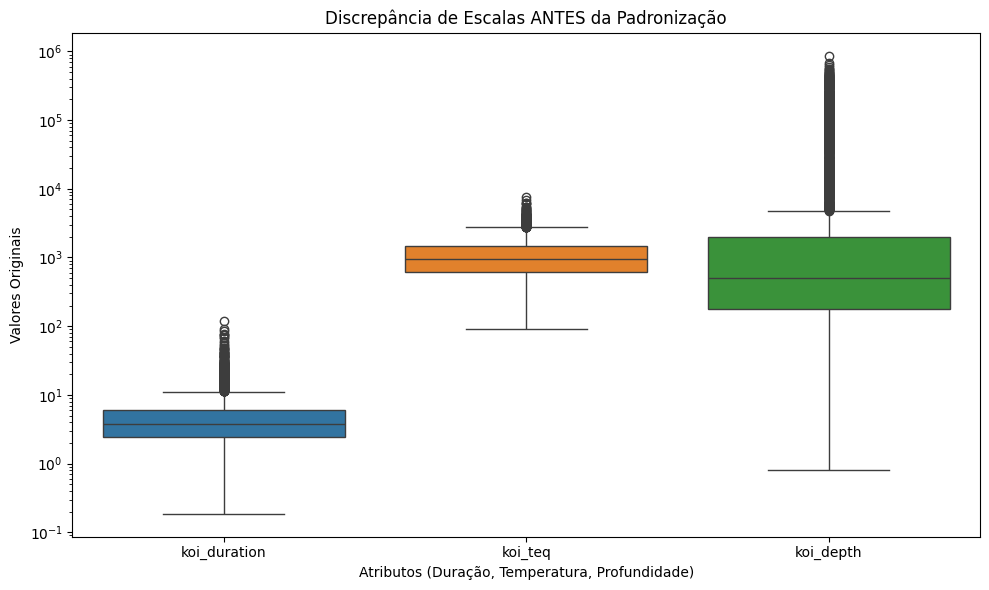

In [8]:
# Configura o tamanho da figura
plt.figure(figsize=(10, 6))

# Plota um boxplot com 3 variáveis de grandezas físicas muito diferentes
sns.boxplot(data=X_train[['koi_duration', 'koi_teq', 'koi_depth']])

# Adiciona títulos
plt.title('Discrepância de Escalas ANTES da Padronização')
plt.ylabel('Valores Originais')
plt.xlabel('Atributos (Duração, Temperatura, Profundidade)')

# Como a profundidade (depth) pode chegar a dezenas de milhares e a duração é um número pequeno,
# usamos a escala logarítmica no eixo Y para conseguir ver as caixas no mesmo gráfico.
plt.yscale('log') 

plt.tight_layout()
plt.show()

**Discrepância de Grandezas:**
O Boxplot expõe a gigantesca diferença matemática entre os atributos. Enquanto a duração do trânsito (`koi_duration`) opera na casa das dezenas, a profundidade da queda de luz (`koi_depth`) atinge milhares de partes por milhão. Essa visualização é a prova  de que a **padronização** aplicada no Tópico 6 era obrigatória. Sem ela, a métrica de profundidade esmagaria as outras variáveis no cálculo de distância geométrica, destruindo a acurácia de modelos como o k-NN e o SVM.

In [9]:
# 1. Inicialização do padronizador
scaler = StandardScaler()

# 2. O 'fit_transform' é aplicado APENAS no X_train para aprender a média e o desvio padrão
X_train_scaled = scaler.fit_transform(X_train)

# 3. O 'transform' é aplicado no X_test usando exatamente a escala aprendida no treino
X_test_scaled = scaler.transform(X_test)

# 4. Convertendo de volta para DataFrame do Pandas para manter os nomes das colunas e os índices
X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("--- Resumo após Padronização ---")
print(f"Média da primeira coluna no treino: {X_train.iloc[:, 0].mean():.2f}")
print(f"Desvio Padrão da primeira coluna no treino: {X_train.iloc[:, 0].std():.2f}")

# Exibe as primeiras linhas para confirmar que todos os valores agora são decimais pequenos
display(X_train.head(3))

--- Resumo após Padronização ---
Média da primeira coluna no treino: 0.00
Desvio Padrão da primeira coluna no treino: 1.00


,koi_period,koi_impact,koi_duration,koi_depth,koi_ror,koi_srho,koi_prad,koi_sma,koi_incl,koi_teq,...,koi_fwm_srao,koi_fwm_sdeco,koi_fwm_prao,koi_fwm_pdeco,koi_dicco_mra,koi_dicco_mdec,koi_dicco_msky,koi_dikco_mra,koi_dikco_mdec,koi_dikco_msky
4350,-0.397286,0.120024,-0.095784,1.750282,0.173254,-0.144620,0.072957,-0.511968,-0.466668,2.392774,...,0.030663,0.060149,0.006914,-0.013845,0.010357,0.038371,-0.594786,0.011199,0.018372,-0.566105
4716,-0.406814,-0.142147,-0.440420,-0.314032,-0.103962,-0.141310,-0.039871,-0.587187,-0.143752,1.094031,...,0.354857,0.291576,0.005860,-0.014738,1.208335,1.138480,0.736301,1.248551,1.243022,0.825474
606,-0.318394,0.289388,-0.161413,-0.299398,0.034993,-0.154984,-0.023110,-0.350373,-0.398095,-0.662313,...,0.033251,-0.040954,0.002567,0.002779,-0.645155,-0.656399,0.193188,-0.729624,-0.742514,0.297687


## 7. Balanceamento de Classes

Em problemas de detecção de anomalias ou eventos raros (como o trânsito de exoplanetas), é comum que o conjunto de dados seja desbalanceado, com uma predominância da classe negativa (falsos positivos) sobre a positiva (confirmados). Um desequilíbrio pode enviesar o modelo de aprendizado de máquina, fazendo com que ele ignore a classe minoritária e maximize a acurácia global apenas prevendo a classe majoritária.

Para não ter este efeito, aplicaremos a técnica SMOTE (Synthetic Minority Over-sampling Technique), que interpola dados para gerar amostras sintéticas da classe minoritária. 

Para preservar a integridade do experimento e prevenir o vazamento de dados, a geração de dados sintéticos será aplicada **ao conjunto de treinamento**. O conjunto de teste manterá a sua distribuição original para refletir a realidade operacional do telescópio.

In [10]:
# 1. Verificando a distribuição ANTES do balanceamento
print("--- Distribuição no Treino ANTES do Balanceamento ---")
contagem_antes = pd.Series(y_train).value_counts()
print(f"Classe 1 (FALSE POSITIVE): {contagem_antes[1]} amostras")
print(f"Classe 0 (CONFIRMED): {contagem_antes[0]} amostras")

# 2. Aplicação do SMOTE
# O random_state garante a reprodutibilidade exigida no trabalho
smote = SMOTE(random_state=42)

# O balanceamento ocorre EXCLUSIVAMENTE nas variáveis de treino
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Atualizando os DataFrames de treino oficiais
X_train = X_train_resampled
y_train = y_train_resampled

# 3. Verificando a distribuição APÓS o balanceamento
print("\n--- Distribuição no Treino APÓS o Balanceamento ---")
contagem_depois = pd.Series(y_train).value_counts()
print(f"Classe 1 (FALSE POSITIVE): {contagem_depois[1]} amostras")
print(f"Classe 0 (CONFIRMED): {contagem_depois[0]} amostras")

--- Distribuição no Treino ANTES do Balanceamento ---
Classe 1 (FALSE POSITIVE): 2168 amostras
Classe 0 (CONFIRMED): 1473 amostras

--- Distribuição no Treino APÓS o Balanceamento ---
Classe 1 (FALSE POSITIVE): 2168 amostras
Classe 0 (CONFIRMED): 2168 amostras


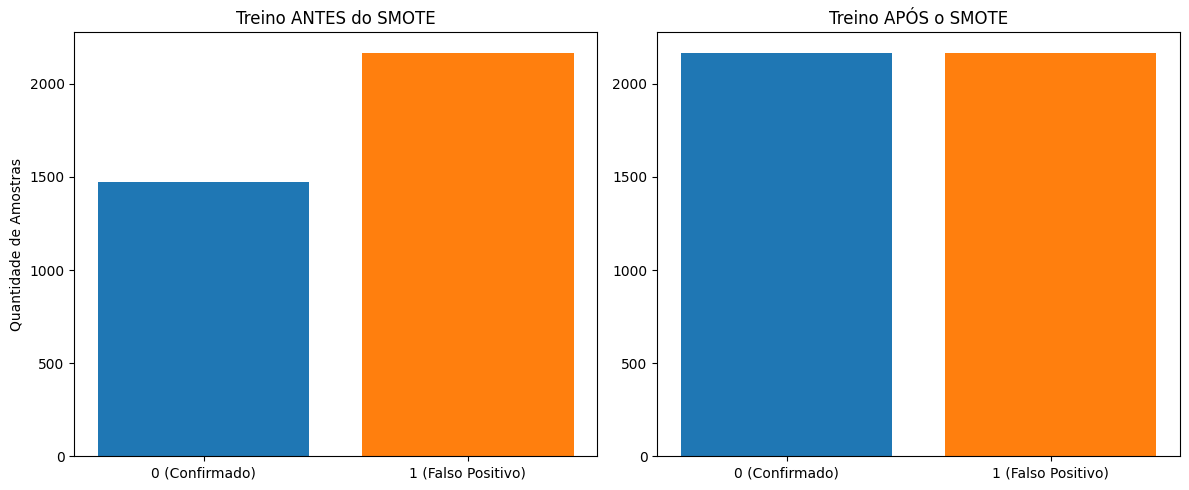

In [11]:
# Criação da figura com dois gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico 1: Antes do SMOTE
axes[0].bar(['0 (Confirmado)', '1 (Falso Positivo)'], 
            [contagem_antes[0], contagem_antes[1]], 
            color=['#1f77b4', '#ff7f0e'])
axes[0].set_title('Treino ANTES do SMOTE')
axes[0].set_ylabel('Quantidade de Amostras')

# Gráfico 2: Após o SMOTE
axes[1].bar(['0 (Confirmado)', '1 (Falso Positivo)'], 
            [contagem_depois[0], contagem_depois[1]], 
            color=['#1f77b4', '#ff7f0e'])
axes[1].set_title('Treino APÓS o SMOTE')

# Ajuste de layout e exibição
plt.tight_layout()
plt.show()

## 8. Treinamento e Validação Cruzada

Nesta etapa, iniciaremos a modelagem preditiva instanciando os seis algoritmos de classificação exigidos: Naive Bayes, Decision Tree, k-Nearest Neighbors (k-NN), Support Vector Machines (SVM), Random Forest e Gradient Tree Boosting.

Para garantir a robustez dos modelos e evitar que eles apenas memorizem os dados (*overfitting*), utilizaremos a técnica de Validação Cruzada (*Cross-Validation*) com 5 dobras (*folds*). É importante ressaltar que, sa fim de previnir *data leakage*, a validação cruzada será aplicada **exclusivamente no conjunto de treinamento**. O conjunto de teste (30%) permanece totalmente isolado para a avaliação final.

In [12]:
# 1. Dicionário com os 6 modelos requisitados
# Utilizamos random_state onde aplicável para garantir reprodutibilidade
modelos = {
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "k-NN": KNeighborsClassifier(),
    "SVM": SVC(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

resultados_cv = {}

print("--- Resultados da Validação Cruzada (Acurácia no Treino - 5 Folds) ---")
for nome, modelo in modelos.items():
    # Aplica a validação cruzada APENAS no conjunto de treino balanceado
    # cv=5 divide o treino em 5 partes, treina em 4 e valida em 1, repetindo 5 vezes.
    scores = cross_val_score(modelo, X_train, y_train, cv=5, scoring='accuracy')
    resultados_cv[nome] = scores
    
    # Imprime a média de acurácia e a margem de erro (2 desvios padrões)
    print(f"{nome:18s}: {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")
    
    # Após a validação, treinamos o modelo final com TODOS os dados de treino

    modelo.fit(X_train, y_train)


--- Resultados da Validação Cruzada (Acurácia no Treino - 5 Folds) ---
Naive Bayes       : 0.9320 (+/- 0.0052)
Decision Tree     : 0.9435 (+/- 0.0322)
k-NN              : 0.8967 (+/- 0.0172)
SVM               : 0.9442 (+/- 0.0116)
Random Forest     : 0.9721 (+/- 0.0143)
Gradient Boosting : 0.9730 (+/- 0.0101)


## 11. Referencial Teórico

* Borucki, W. J., et al. (2010). Kepler Planet-Detection Mission: Introduction and First Results. *Science*, 327(5968), 977-980.
* Morton, T. D., et al. (2016). False Positive Probabilities for all Kepler Objects of Interest: 1284 Newly Confirmed Planets and 428 Likely False Positives. *The Astrophysical Journal*, 822(2), 86.
* Shallue, C. J., & Vanderburg, A. (2018). Identifying Exoplanets with Deep Learning: A Five-planet Resonant Chain around Kepler-80 and an Eighth Planet around Kepler-90. *The Astronomical Journal*, 155(2), 94.